------

In [1]:
from pathlib import Path
import os, sys, shutil

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
import random

In [2]:
from src.logger import create_jupyter_logger
from src.utils import visualize_cvrp_scatter
from src.alns import ALNSSolver, VRPParser

level = "DEBUG"
logger = create_jupyter_logger(name=__name__, level=level, level_width=8)
parser = VRPParser()

In [3]:
def seed_everything(seed: int = 42) -> None:
    logger.info("Using seed value: %s" % seed)
    random.seed(seed)
    
seed_everything(seed=3407)

2026-03-14 17:19:39 |   INFO   | __main__ | Using seed value: 3407


------

In [4]:
# Detect available sets of data ...
available_sets = os.listdir("./data/raw")

for i, available_set in enumerate(available_sets):
    list_of_files = os.listdir(f"./data/raw/{available_set}")
    
    vrp_files = [file_nm for file_nm in list_of_files if file_nm.endswith(".vrp")]
    sol_files = [file_nm for file_nm in list_of_files if file_nm.endswith(".sol")]
    logger.info(
        "Set '%s': %-2s - .vrp files, %-2s - .sol files"
        % (available_set, len(vrp_files), len(sol_files)))

2026-03-14 17:19:39 |   INFO   | __main__ | Set 'E': 13 - .vrp files, 13 - .sol files
2026-03-14 17:19:39 |   INFO   | __main__ | Set 'F': 3  - .vrp files, 3  - .sol files
2026-03-14 17:19:39 |   INFO   | __main__ | Set 'M': 5  - .vrp files, 5  - .sol files
2026-03-14 17:19:39 |   INFO   | __main__ | Set 'P': 24 - .vrp files, 24 - .sol files


----

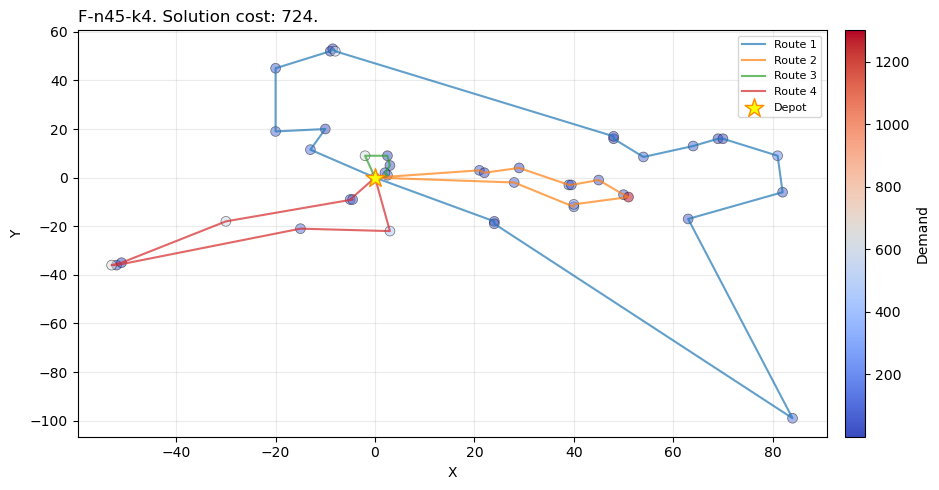

In [5]:
# Visualize current problem information on scatter plot ...
problem_pth = f"./data/raw/F/F-n45-k4"
vrp_data = VRPParser.parse_vrp(path=problem_pth + ".vrp").__dict__
sol_data = VRPParser.parse_sol(path=problem_pth + ".sol")

visualize_cvrp_scatter(
    data=vrp_data, solution=sol_data, data_nm=vrp_data["name"])

-----

In [ ]:
# Start solving all available sets of data ...
from tqdm import tqdm_notebook as tqdm
import time

summary_pdf = pd.DataFrame(
    columns=[
        "Problem name",
        "ALNS.max_iter", "ALNS.cooling", "ALNS.start_temp", 
        "Optimal cost", "ALNS.cost", "Deviation (%)", "Elapsed time (sec.)",
        "Optimal routes", "ALNS.routes"
    ]
)

for max_iter in tqdm([100, 250, 500, 1000, 2000, 5000]):
    for cooling in [0.5, 0.75, 0.9, 0.995]:
        for start_temp in [1.0, 50.0, 75.0, 100.0]:
            alns = ALNSSolver(
                max_iter=max_iter,
                cooling=cooling,
                start_temp=start_temp
            )

            # Find all available .vrp files ...
            for set_nm in ["E", "F", "M", "P"]:
                problem_nms = [
                    val.replace(".vrp", "")
                    for val in os.listdir(f"./data/raw/{set_nm}")
                    if val.endswith(".vrp")
                    
                ]
                for problem_nm in problem_nms:
                    problem_path = f"./data/raw/{set_nm}/{problem_nm}"
                    
                    instance = parser.parse_vrp(problem_path + ".vrp")
                    solution = parser.parse_sol(problem_path + ".sol")

                    start_time = time.time()
                    alns_solution, best_cost = alns.solve(instance)
                    alns_routes = [
                        route.to_list()
                        for route in alns_solution.routes
                    ]
                    deviation = round(
                        abs(
                            solution["cost"] - best_cost
                        ) / solution["cost"] * 100,
                        1
                    )
                    elapsed_time = time.time() - start_time

                    summary_pdf = pd.concat(
                        (
                            summary_pdf,
                            pd.DataFrame(
                                data=[
                                    problem_nm,
                                    max_iter, cooling, start_temp,
                                    solution["cost"], best_cost, deviation,
                                    elapsed_time,
                                    solution["routes"], alns_routes
                                ],
                                index=summary_pdf.columns
                            ).T
                        ),
                        axis=0,
                        ignore_index=True
                    )

-------